In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier


In [2]:
df_test_f = pd.read_csv('test_final_processed.csv')
df_test_f

,sk_id_curr,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,...,ip_version_56.0_mean,ip_version_57.0_mean,ip_version_58.0_mean,ip_version_59.0_mean,ip_version_61.0_mean,ip_version_68.0_mean,ip_version_72.0_mean,ip_version_73.0_mean,ip_version_178.0_mean,ip_version_nan_mean
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48739,456221,Cash loans,F,N,Y,0,121500.0,412560.0,17473.5,270000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48740,456222,Cash loans,F,N,N,2,157500.0,622413.0,31909.5,495000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48741,456223,Cash loans,F,Y,Y,1,202500.0,315000.0,33205.5,315000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48742,456224,Cash loans,M,N,N,0,225000.0,450000.0,25128.0,450000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df_test_f = pd.read_csv('test_final_processed.csv')
df_test_f

,sk_id_curr,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,...,ip_version_56.0_mean,ip_version_57.0_mean,ip_version_58.0_mean,ip_version_59.0_mean,ip_version_61.0_mean,ip_version_68.0_mean,ip_version_72.0_mean,ip_version_73.0_mean,ip_version_178.0_mean,ip_version_nan_mean
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48739,456221,Cash loans,F,N,Y,0,121500.0,412560.0,17473.5,270000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48740,456222,Cash loans,F,N,N,2,157500.0,622413.0,31909.5,495000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48741,456223,Cash loans,F,Y,Y,1,202500.0,315000.0,33205.5,315000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48742,456224,Cash loans,M,N,N,0,225000.0,450000.0,25128.0,450000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df_train_f = pd.read_csv('train_final_processed.csv')
df_train_f

,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,...,ip_version_56.0_mean,ip_version_57.0_mean,ip_version_58.0_mean,ip_version_59.0_mean,ip_version_61.0_mean,ip_version_68.0_mean,ip_version_72.0_mean,ip_version_73.0_mean,ip_version_178.0_mean,ip_version_nan_mean
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
print(df_train_f.isnull().sum().sum())
print(df_test_f.isnull().sum().sum())


0
0


In [14]:
df_train_f['target'].value_counts()

target
0    282686
1     24825
Name: count, dtype: int64

In [27]:
print("Доля target=1 в df_train_f:", df_train_f['target'].mean())

Доля target=1 в df_train_f: 0.08072881945686496


Создание BaseModel

In [6]:
X = df_train_f.drop(columns=['sk_id_curr', 'target'])
y = df_train_f['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
categorical_columns = X_train.select_dtypes(include=['object']).columns
print(f"Категориальные колонки: {list(categorical_columns)}")

X_train_encoded = pd.get_dummies(X_train, columns=categorical_columns, prefix=categorical_columns, drop_first=True)

Категориальные колонки: ['name_contract_type', 'code_gender', 'flag_own_car', 'flag_own_realty', 'name_type_suite', 'name_income_type', 'name_education_type', 'name_family_status', 'name_housing_type', 'occupation_type', 'weekday_appr_process_start', 'organization_type', 'fondkapremont_mode', 'housetype_mode', 'wallsmaterial_mode', 'emergencystate_mode']


In [8]:
X_val_encoded = pd.get_dummies(X_val, columns=categorical_columns, prefix=categorical_columns, drop_first=True)

for col in X_train_encoded.columns:
    if col not in X_val_encoded.columns:
        X_val_encoded[col] = 0

X_val_encoded = X_val_encoded[X_train_encoded.columns]

Gradient Boosting

In [50]:
base_model = GradientBoostingClassifier(random_state=42)
base_model.fit(X_train_encoded, y_train)

GradientBoostingClassifier(random_state=42)

In [51]:
y_val_pred_proba = base_model.predict_proba(X_val_encoded)[:, 1]
y_val_pred = (y_val_pred_proba >= 0.5).astype(int)

In [52]:
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred) 
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_pred_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

ROC-AUC: 0.7684
Accuracy: 0.9201
Precision: 0.5855
Recall: 0.0228
F1-Score: 0.0440


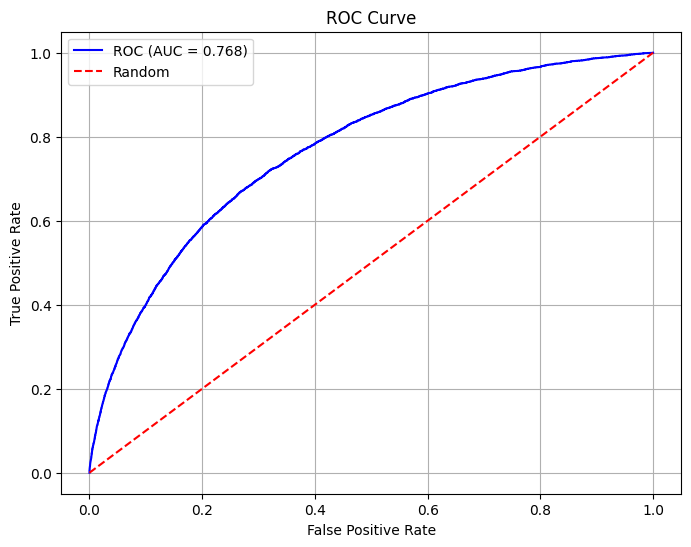

In [ ]:
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

Random Forest

In [67]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_encoded, y_train)

RandomForestClassifier(random_state=42)

In [68]:
y_pred_rf_proba = rf_model.predict_proba(X_val_encoded)[:, 1]
y_pred_rf = (y_pred_rf_proba >= 0.5).astype(int)

In [69]:
rf_auc = roc_auc_score(y_val, y_pred_rf_proba)
rf_accuracy = accuracy_score(y_val, y_pred_rf)
rf_precision = precision_score(y_val, y_pred_rf)
rf_recall = recall_score(y_val, y_pred_rf)
rf_f1 = f1_score(y_val, y_pred_rf)

print(f"ROC-AUC: {rf_auc:.4f}")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-Score: {rf_f1:.4f}")

ROC-AUC: 0.7159
Accuracy: 0.9195
Precision: 0.5263
Recall: 0.0020
F1-Score: 0.0040


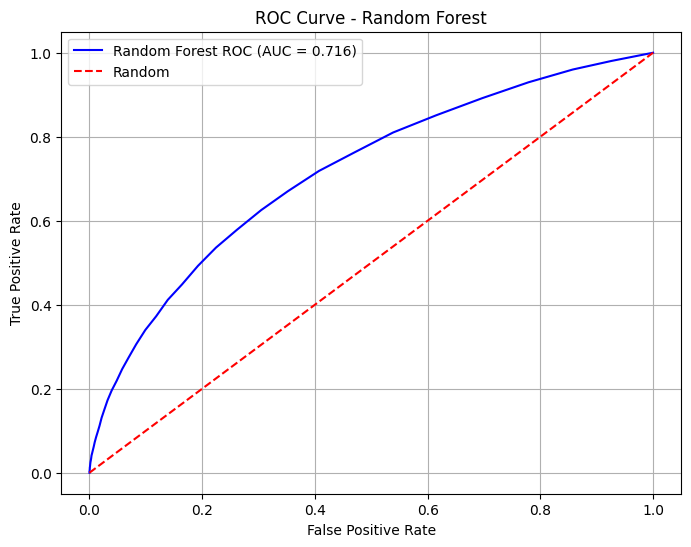

In [70]:
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_pred_rf_proba)
roc_auc_xgb = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, 'b-', label=f'Random Forest ROC (AUC = {roc_auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.grid(True)
plt.show()

алгоритм XGBoost

In [53]:
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_encoded, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [54]:
y_pred_xgb_proba = xgb_model.predict_proba(X_val_encoded)[:, 1]
y_pred_xgb = (y_pred_xgb_proba >= 0.5).astype(int)

In [55]:
xgb_auc = roc_auc_score(y_val, y_pred_xgb_proba)
xgb_accuracy = accuracy_score(y_val, y_pred_xgb)
xgb_precision = precision_score(y_val, y_pred_xgb)
xgb_recall = recall_score(y_val, y_pred_xgb)
xgb_f1 = f1_score(y_val, y_pred_xgb)

print(f"ROC-AUC: {xgb_auc:.4f}")
print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall: {xgb_recall:.4f}")
print(f"F1-Score: {xgb_f1:.4f}")

ROC-AUC: 0.7689
Accuracy: 0.9193
Precision: 0.4898
Recall: 0.0725
F1-Score: 0.1264


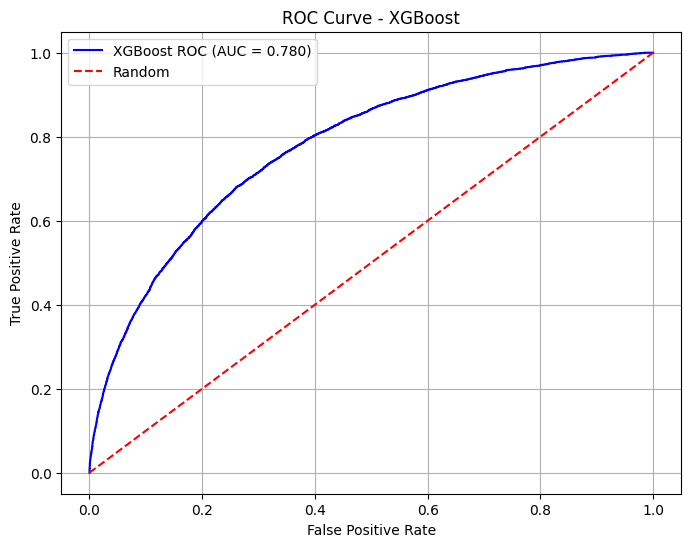

In [47]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_pred_xgb_proba)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, 'b-', label=f'XGBoost ROC (AUC = {roc_auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.grid(True)
plt.show()

CatBoost

In [9]:

cat_model = CatBoostClassifier(random_state=42)
cat_model.fit(X_train_encoded, y_train)

Learning rate set to 0.108111
0:	learn: 0.5862566	total: 402ms	remaining: 6m 41s
1:	learn: 0.5090415	total: 698ms	remaining: 5m 48s
2:	learn: 0.4482182	total: 980ms	remaining: 5m 25s
3:	learn: 0.4043388	total: 1.26s	remaining: 5m 14s
4:	learn: 0.3688892	total: 1.58s	remaining: 5m 15s
5:	learn: 0.3429583	total: 1.94s	remaining: 5m 22s
6:	learn: 0.3236100	total: 2.19s	remaining: 5m 10s
7:	learn: 0.3083423	total: 2.45s	remaining: 5m 4s
8:	learn: 0.2972312	total: 2.81s	remaining: 5m 8s
9:	learn: 0.2887218	total: 3.02s	remaining: 4m 59s
10:	learn: 0.2818421	total: 3.29s	remaining: 4m 56s
11:	learn: 0.2765891	total: 3.5s	remaining: 4m 48s
12:	learn: 0.2722867	total: 3.85s	remaining: 4m 52s
13:	learn: 0.2682653	total: 4.16s	remaining: 4m 53s
14:	learn: 0.2650972	total: 4.46s	remaining: 4m 53s
15:	learn: 0.2628897	total: 4.73s	remaining: 4m 51s
16:	learn: 0.2607559	total: 5.03s	remaining: 4m 50s
17:	learn: 0.2591162	total: 5.36s	remaining: 4m 52s
18:	learn: 0.2577350	total: 5.74s	remaining: 4m

In [10]:
y_pred_cat_proba = cat_model.predict_proba(X_val_encoded)[:, 1]
y_pred_cat = (y_pred_cat_proba >= 0.5).astype(int)


In [11]:
cat_auc = roc_auc_score(y_val, y_pred_cat_proba)
cat_accuracy = accuracy_score(y_val, y_pred_cat)
cat_precision = precision_score(y_val, y_pred_cat)
cat_recall = recall_score(y_val, y_pred_cat)
cat_f1 = f1_score(y_val, y_pred_cat)

print(f"ROC-AUC: {cat_auc:.4f}")
print(f"Accuracy: {cat_accuracy:.4f}")
print(f"Precision: {cat_precision:.4f}")
print(f"Recall: {cat_recall:.4f}")
print(f"F1-Score: {cat_f1:.4f}")

ROC-AUC: 0.7848
Accuracy: 0.9207
Precision: 0.5711
Recall: 0.0576
F1-Score: 0.1046


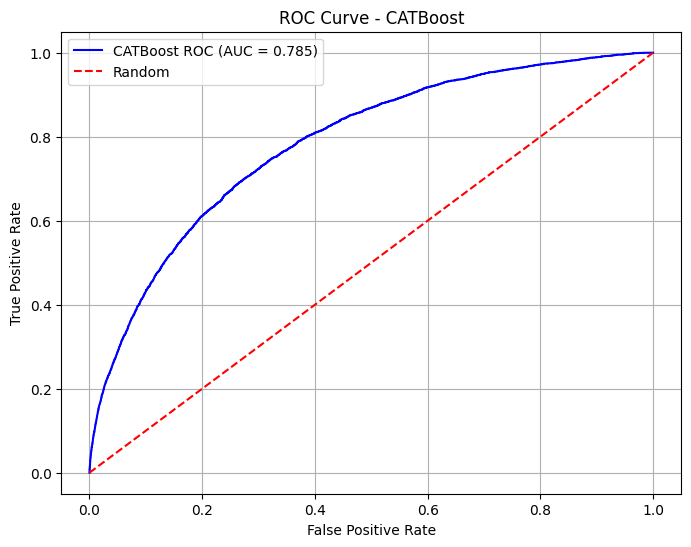

In [ ]:
fpr_cat, tpr_cat, _ = roc_curve(y_val, y_pred_cat_proba)
roc_auc_cat = auc(fpr_cat, tpr_cat)

plt.figure(figsize=(8, 6))
plt.plot(fpr_cat, tpr_cat, 'b-', label=f'CatBoost ROC (AUC = {roc_auc_cat:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve - CatBoost')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def clean_column_names(df):
    clean_columns = []
    for col in df.columns:
        clean_col = re.sub(r'[^a-zA-Z0-9_]', '_', col)
        clean_col = re.sub(r'_+', '_', clean_col)
        clean_col = clean_col.strip('_')
        clean_columns.append(clean_col)
    df.columns = clean_columns
    return df

X_train_clean = clean_column_names(X_train_encoded.copy())
X_val_clean = clean_column_names(X_val_encoded.copy())


In [73]:
lgb_model = LGBMClassifier(random_state=42)
lgb_model.fit(X_train_clean, y_train)

LGBMClassifier(random_state=42)

In [74]:
y_pred_lgb_proba = lgb_model.predict_proba(X_val_encoded)[:, 1]
y_pred_lgb = (y_pred_lgb_proba >= 0.5).astype(int)

In [75]:
lgb_auc = roc_auc_score(y_val, y_pred_lgb_proba)
lgb_accuracy = accuracy_score(y_val, y_pred_lgb)
lgb_precision = precision_score(y_val, y_pred_lgb)
lgb_recall = recall_score(y_val, y_pred_lgb)
lgb_f1 = f1_score(y_val, y_pred_lgb)

print(f"ROC-AUC: {lgb_auc:.4f}")
print(f"Accuracy: {lgb_accuracy:.4f}")
print(f"Precision: {lgb_precision:.4f}")
print(f"Recall: {lgb_recall:.4f}")
print(f"F1-Score: {lgb_f1:.4f}")

ROC-AUC: 0.7773
Accuracy: 0.9201
Precision: 0.5556
Recall: 0.0344
F1-Score: 0.0647


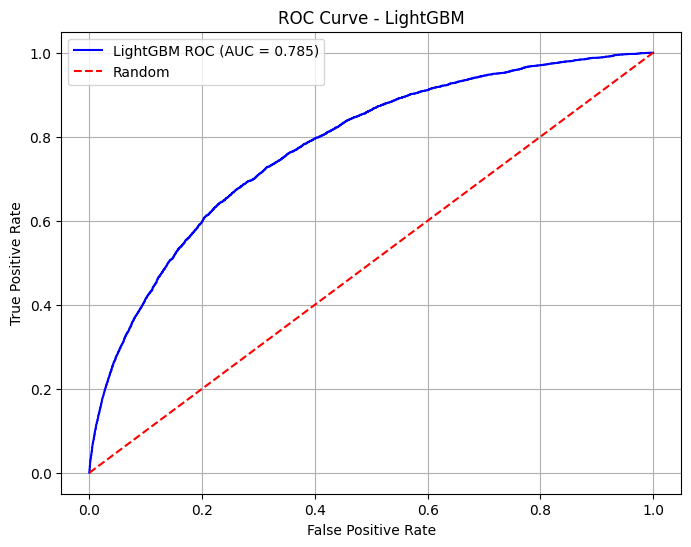

In [76]:
fpr_lgb, tpr_lgb, _ = roc_curve(y_val, y_pred_lgb_proba)
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lgb, tpr_lgb, 'b-', label=f'LightGBM ROC (AUC = {roc_auc_cat:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve - LightGBM')
plt.legend()
plt.grid(True)
plt.show()

Настройка CatBoost

In [16]:
cat_model = CatBoostClassifier(
    iterations=500,                   
    learning_rate=0.05,                
    depth=6,                           
    l2_leaf_reg=3,                     
    random_state=42,
    verbose=100,                                
    auto_class_weights='Balanced',     
    eval_metric='AUC',                                   
    loss_function='Logloss')
cat_model.fit(X_train_encoded, y_train)

0:	total: 404ms	remaining: 3m 21s
100:	total: 29.4s	remaining: 1m 55s
200:	total: 55.6s	remaining: 1m 22s
300:	total: 1m 22s	remaining: 54.4s
400:	total: 1m 48s	remaining: 26.8s
499:	total: 2m 13s	remaining: 0us


In [17]:
y_pred_cat_proba = cat_model.predict_proba(X_val_encoded)[:, 1]
y_pred_cat = (y_pred_cat_proba >= 0.5).astype(int)


In [18]:
cat_auc = roc_auc_score(y_val, y_pred_cat_proba)
cat_accuracy = accuracy_score(y_val, y_pred_cat)
cat_precision = precision_score(y_val, y_pred_cat)
cat_recall = recall_score(y_val, y_pred_cat)
cat_f1 = f1_score(y_val, y_pred_cat)

print(f"ROC-AUC: {cat_auc:.4f}")
print(f"Accuracy: {cat_accuracy:.4f}")
print(f"Precision: {cat_precision:.4f}")
print(f"Recall: {cat_recall:.4f}")
print(f"F1-Score: {cat_f1:.4f}")

ROC-AUC: 0.7820
Accuracy: 0.7291
Precision: 0.1840
Recall: 0.6888
F1-Score: 0.2904


In [19]:
cat_model_balanced = CatBoostClassifier(
    iterations=500,                   
    learning_rate=0.05,                
    depth=6,                           
    l2_leaf_reg=3,                     
    random_state=42,
    verbose=100,                                
    scale_pos_weight=3,  
    eval_metric='AUC',                                   
    loss_function='Logloss'
)
cat_model_balanced.fit(X_train_encoded, y_train)

0:	total: 418ms	remaining: 3m 28s
100:	total: 30.6s	remaining: 2m
200:	total: 57.9s	remaining: 1m 26s
300:	total: 1m 24s	remaining: 55.7s
400:	total: 1m 49s	remaining: 27s
499:	total: 2m 14s	remaining: 0us


In [20]:
y_pred_cat_proba = cat_model_balanced.predict_proba(X_val_encoded)[:, 1]
y_pred_cat = (y_pred_cat_proba >= 0.5).astype(int)

In [21]:
cat_auc = roc_auc_score(y_val, y_pred_cat_proba)
cat_accuracy = accuracy_score(y_val, y_pred_cat)
cat_precision = precision_score(y_val, y_pred_cat)
cat_recall = recall_score(y_val, y_pred_cat)
cat_f1 = f1_score(y_val, y_pred_cat)

print(f"ROC-AUC: {cat_auc:.4f}")
print(f"Accuracy: {cat_accuracy:.4f}")
print(f"Precision: {cat_precision:.4f}")
print(f"Recall: {cat_recall:.4f}")
print(f"F1-Score: {cat_f1:.4f}")

ROC-AUC: 0.7832
Accuracy: 0.9069
Precision: 0.3722
Recall: 0.2289
F1-Score: 0.2835


In [25]:
cat_model_optimal = CatBoostClassifier(
    iterations=1000,     
    learning_rate=0.08,       
    depth=7,          
    scale_pos_weight=2.5,  
    l2_leaf_reg=4,                    
    random_strength=0.8,              
    bagging_temperature=0.8,  
    subsample=0.85,                   
    colsample_bylevel=0.85,           
    min_data_in_leaf=50,             
    random_state=42,
    verbose=100,
    thread_count=-1,
    early_stopping_rounds=50,    
    loss_function='Logloss',
    eval_metric='AUC'               
    )
cat_model_optimal.fit(X_train_encoded, y_train)

0:	total: 543ms	remaining: 9m 2s
100:	total: 47.7s	remaining: 7m 4s
200:	total: 1m 28s	remaining: 5m 52s
300:	total: 2m 9s	remaining: 5m 1s
400:	total: 2m 48s	remaining: 4m 11s
500:	total: 3m 28s	remaining: 3m 27s
600:	total: 4m 15s	remaining: 2m 49s
700:	total: 4m 56s	remaining: 2m 6s
800:	total: 5m 36s	remaining: 1m 23s
900:	total: 6m 16s	remaining: 41.4s
999:	total: 6m 55s	remaining: 0us


In [26]:
y_pred_cat_proba = cat_model_optimal.predict_proba(X_val_encoded)[:, 1]
y_pred_cat = (y_pred_cat_proba >= 0.5).astype(int)

In [27]:
cat_auc = roc_auc_score(y_val, y_pred_cat_proba)
cat_accuracy = accuracy_score(y_val, y_pred_cat)
cat_precision = precision_score(y_val, y_pred_cat)
cat_recall = recall_score(y_val, y_pred_cat)
cat_f1 = f1_score(y_val, y_pred_cat)

print(f"ROC-AUC: {cat_auc:.4f}")
print(f"Accuracy: {cat_accuracy:.4f}")
print(f"Precision: {cat_precision:.4f}")
print(f"Recall: {cat_recall:.4f}")
print(f"F1-Score: {cat_f1:.4f}")

ROC-AUC: 0.7840
Accuracy: 0.9135
Precision: 0.4166
Recall: 0.1863
F1-Score: 0.2575


In [28]:
cat_model_optimal = CatBoostClassifier(
    iterations=500,     
    learning_rate=0.08,       
    depth=6,          
    auto_class_weights='SqrtBalanced',
    random_state=42,
    eval_metric='AUC'               
    )
cat_model_optimal.fit(X_train_encoded, y_train)

0:	total: 884ms	remaining: 7m 21s
1:	total: 1.17s	remaining: 4m 52s
2:	total: 1.69s	remaining: 4m 39s
3:	total: 1.99s	remaining: 4m 6s
4:	total: 2.35s	remaining: 3m 52s
5:	total: 2.62s	remaining: 3m 35s
6:	total: 2.9s	remaining: 3m 24s
7:	total: 3.21s	remaining: 3m 17s
8:	total: 3.55s	remaining: 3m 13s
9:	total: 3.84s	remaining: 3m 8s
10:	total: 4.48s	remaining: 3m 19s
11:	total: 4.97s	remaining: 3m 22s
12:	total: 5.36s	remaining: 3m 20s
13:	total: 5.73s	remaining: 3m 18s
14:	total: 5.98s	remaining: 3m 13s
15:	total: 6.28s	remaining: 3m 9s
16:	total: 6.53s	remaining: 3m 5s
17:	total: 6.84s	remaining: 3m 3s
18:	total: 7.19s	remaining: 3m 1s
19:	total: 7.48s	remaining: 2m 59s
20:	total: 7.8s	remaining: 2m 57s
21:	total: 8.09s	remaining: 2m 55s
22:	total: 8.39s	remaining: 2m 54s
23:	total: 8.69s	remaining: 2m 52s
24:	total: 9.04s	remaining: 2m 51s
25:	total: 9.38s	remaining: 2m 50s
26:	total: 9.82s	remaining: 2m 52s
27:	total: 10.4s	remaining: 2m 55s
28:	total: 10.9s	remaining: 2m 57s
29:

In [29]:
y_pred_cat_proba = cat_model_optimal.predict_proba(X_val_encoded)[:, 1]
y_pred_cat = (y_pred_cat_proba >= 0.5).astype(int)

In [30]:
cat_auc = roc_auc_score(y_val, y_pred_cat_proba)
cat_accuracy = accuracy_score(y_val, y_pred_cat)
cat_precision = precision_score(y_val, y_pred_cat)
cat_recall = recall_score(y_val, y_pred_cat)
cat_f1 = f1_score(y_val, y_pred_cat)

print(f"ROC-AUC: {cat_auc:.4f}")
print(f"Accuracy: {cat_accuracy:.4f}")
print(f"Precision: {cat_precision:.4f}")
print(f"Recall: {cat_recall:.4f}")
print(f"F1-Score: {cat_f1:.4f}")

ROC-AUC: 0.7841
Accuracy: 0.9009
Precision: 0.3483
Recall: 0.2665
F1-Score: 0.3020


In [ ]:
cat_model_optimal = CatBoostClassifier(
    iterations=500,     
    learning_rate=0.05,       
    depth=7,          
    auto_class_weights='SqrtBalanced',
    random_state=42,
    l2_leaf_reg=3,  
    eval_metric='AUC',
    loss_function='Logloss',
    verbose=100,            
    )
cat_model_optimal.fit(X_train_encoded, y_train)

0:	total: 663ms	remaining: 5m 30s
100:	total: 41.4s	remaining: 2m 43s
200:	total: 1m 19s	remaining: 1m 58s
300:	total: 1m 56s	remaining: 1m 17s
400:	total: 2m 33s	remaining: 37.9s
499:	total: 3m 7s	remaining: 0us


In [32]:
y_pred_cat_proba = cat_model_optimal.predict_proba(X_val_encoded)[:, 1]
y_pred_cat = (y_pred_cat_proba >= 0.5).astype(int)

In [33]:
cat_auc = roc_auc_score(y_val, y_pred_cat_proba)
cat_accuracy = accuracy_score(y_val, y_pred_cat)
cat_precision = precision_score(y_val, y_pred_cat)
cat_recall = recall_score(y_val, y_pred_cat)
cat_f1 = f1_score(y_val, y_pred_cat)

print(f"ROC-AUC: {cat_auc:.4f}")
print(f"Accuracy: {cat_accuracy:.4f}")
print(f"Precision: {cat_precision:.4f}")
print(f"Recall: {cat_recall:.4f}")
print(f"F1-Score: {cat_f1:.4f}")

ROC-AUC: 0.7840
Accuracy: 0.9020
Precision: 0.3521
Recall: 0.2594
F1-Score: 0.2987


In [ ]:
#оптимальная!!!
cat_model_optimal = CatBoostClassifier(
    iterations=1000,     
    learning_rate=0.03,       
    depth=7,          
    auto_class_weights='SqrtBalanced',
    random_state=42,
    l2_leaf_reg=2,  
    eval_metric='AUC',
    loss_function='Logloss',
    verbose=100,            
    )
cat_model_optimal.fit(X_train_encoded, y_train)

0:	total: 628ms	remaining: 10m 27s
100:	total: 38.6s	remaining: 5m 43s
200:	total: 1m 15s	remaining: 5m 2s
300:	total: 1m 55s	remaining: 4m 27s
400:	total: 2m 30s	remaining: 3m 45s
500:	total: 3m 4s	remaining: 3m 3s
600:	total: 3m 40s	remaining: 2m 26s
700:	total: 4m 14s	remaining: 1m 48s
800:	total: 4m 48s	remaining: 1m 11s
900:	total: 5m 21s	remaining: 35.3s
999:	total: 5m 55s	remaining: 0us


In [35]:
y_pred_cat_proba = cat_model_optimal.predict_proba(X_val_encoded)[:, 1]
y_pred_cat = (y_pred_cat_proba >= 0.5).astype(int)

In [36]:
cat_auc = roc_auc_score(y_val, y_pred_cat_proba)
cat_accuracy = accuracy_score(y_val, y_pred_cat)
cat_precision = precision_score(y_val, y_pred_cat)
cat_recall = recall_score(y_val, y_pred_cat)
cat_f1 = f1_score(y_val, y_pred_cat)

print(f"ROC-AUC: {cat_auc:.4f}")
print(f"Accuracy: {cat_accuracy:.4f}")
print(f"Precision: {cat_precision:.4f}")
print(f"Recall: {cat_recall:.4f}")
print(f"F1-Score: {cat_f1:.4f}")

ROC-AUC: 0.7853
Accuracy: 0.9032
Precision: 0.3608
Recall: 0.2637
F1-Score: 0.3047


In [ ]:
cat_model_optimal = CatBoostClassifier(
    iterations=1000,     
    learning_rate=0.03,       
    depth=7,          
    auto_class_weights='SqrtBalanced',
    random_state=42,
    l2_leaf_reg=2,
    eval_metric='Recall',
    loss_function='Logloss',
    verbose=100,            
    )
cat_model_optimal.fit(X_train_encoded, y_train)

0:	learn: 0.0960455	total: 337ms	remaining: 2m 48s
100:	learn: 0.1776011	total: 32.4s	remaining: 2m 8s
200:	learn: 0.2291205	total: 1m 3s	remaining: 1m 34s
300:	learn: 0.2625277	total: 1m 36s	remaining: 1m 3s
400:	learn: 0.2852687	total: 2m 5s	remaining: 31s
499:	learn: 0.3019219	total: 2m 33s	remaining: 0us


In [42]:
y_pred_cat_proba = cat_model_optimal.predict_proba(X_val_encoded)[:, 1]
y_pred_cat = (y_pred_cat_proba >= 0.5).astype(int)

In [43]:
cat_auc = roc_auc_score(y_val, y_pred_cat_proba)
cat_accuracy = accuracy_score(y_val, y_pred_cat)
cat_precision = precision_score(y_val, y_pred_cat)
cat_recall = recall_score(y_val, y_pred_cat)
cat_f1 = f1_score(y_val, y_pred_cat)

print(f"ROC-AUC: {cat_auc:.4f}")
print(f"Accuracy: {cat_accuracy:.4f}")
print(f"Precision: {cat_precision:.4f}")
print(f"Recall: {cat_recall:.4f}")
print(f"F1-Score: {cat_f1:.4f}")

ROC-AUC: 0.7831
Accuracy: 0.9017
Precision: 0.3533
Recall: 0.2661
F1-Score: 0.3036
